[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/spirosChv/neuro208-tutorials/blob/main/Practical_NEURON_and_DendroTweaks/Jaxley_tutorial.ipynb)

# Jaxley: The Basics

In [1]:
!pip install jaxley --quiet

In [2]:
import jax
from jax import jit

# Enable float64 (recommended for stability with morphologically detailed neurons)
jax.config.update("jax_enable_x64", True)

# Tell JAX to use GPU
jax.config.update("jax_platform_name", "gpu")  # falls back to CPU if no GPU found

In [3]:
print(jax.devices())  # should show CudaDevice

[CudaDevice(id=0)]


In [4]:
import numpy as np
import random
import matplotlib.pyplot as plt
import json
import os
import time

In [5]:
import jaxley as jx
import jax.numpy as jnp
from jax import jit, vmap

In [6]:
!rm -rf data

In [7]:
# @markdown Create data directories
path_to_mod = os.path.join(os.getcwd(), 'data', 'mod')
path_to_swc = os.path.join(os.getcwd(), 'data', 'swc')

if not os.path.exists(path_to_mod):
    os.makedirs(path_to_mod)
if not os.path.exists(path_to_swc):
    os.makedirs(path_to_swc)

## Morphology

In [8]:
# @markdown SWC file for simplified neuronal morphology
with open(os.path.join(path_to_swc, 'cell.swc'), 'w') as f:
    f.write("""# uid type x y z radius parent
1 1 0 0 0 10 -1
2 2 0 -10 0 1.0 1
3 2 0 -60 0 1.0 2
4 3 -10 -10 0 0.5 1
5 3 -150 -150 0 0.2 4
6 3 10 -10 0 0.5 1
7 3 150 -150 0 0.2 6
8 3 -10 10 0 0.5 1
9 3 -150 150 0 0.2 8
10 3 10 10 0 0.5 1
11 3 150 150 0 0.2 10
12 4 0 10 0 1 1
13 4 0 150 0 0.5 12
14 4 0 250 0 0.5 13
15 4 -200 400 0 0.2 14
16 4 200 400 0 0.2 14
""")

In [9]:
path_to_swc_file = os.path.join(os.getcwd(), 'data', 'swc', 'cell.swc')
cell = jx.read_swc(path_to_swc_file, ncomp=1)

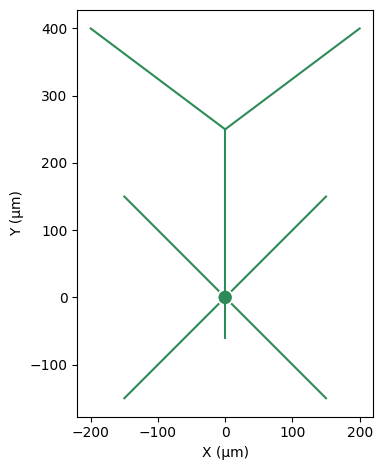

In [10]:
fig, ax = plt.subplots()
cell.vis(ax=ax, color="seagreen")
ax.set_aspect("equal")
ax.set_xlabel("X (µm)")
ax.set_ylabel("Y (µm)")
plt.tight_layout()

## Biophysics

In [11]:
from jaxley.channels import Channel
from jaxley.solver_gate import exponential_euler
import jax.numpy as np

In [12]:
class Nav(Channel):
    """
    Standardized sodium channel
    """

    def __init__(self, name="Nav"):
        self.current_is_in_mA_per_cm2 = True
        super().__init__(name=name)
        self.channel_params = {
            "gbar_Nav": 0.0,
            "vhalf_m_Nav": -32.571,
            "sigma_m_Nav": 9.8,
            "k_m_Nav": 1.882,
            "delta_m_Nav": 0.541,
            "tau0_m_Nav": 0.065,
            "vhalf_h_Nav": -60.0,
            "sigma_h_Nav": -6.2,
            "k_h_Nav": 0.018,
            "delta_h_Nav": 0.395,
            "tau0_h_Nav": 0.797,
            "q10_Nav": 2.3,
            "temp_Nav": 23,
            "ena": 60
            }
        self.channel_states = {
            "m_Nav": 0.0,
            "h_Nav": 0.0
            }
        self._state_powers = {
            "m_Nav": {'power': 3},
            "h_Nav": {'power': 1}
            }
        self.ion = "na"
        self.current_name = "i_na"

        self.independent_var_name = "v"
        self.tadj = 1

    def set_tadj(self, temperature):
        q10 = self.channel_params.get(f"q10_Nav")
        reference_temp = self.channel_params.get(f"temp_Nav")
        if q10 is None or reference_temp is None:
            self.tadj = 1
            print(f"Warning: q10 or reference temperature not set for {self.name}. Using default tadj = 1.")
        else:
            self.tadj = q10 ** ((temperature - reference_temp) / 10)

    def __getitem__(self, item):
        return self.channel_params[item]

    def __setitem__(self, item, value):
        self.channel_params[item] = value


    def alpha_prime(self, v, k, delta, vhalf, sigma):
        alpha_prime = k * np.exp(((delta * (v - vhalf)) / sigma))
        return alpha_prime


    def beta_prime(self, v, k, delta, vhalf, sigma):
        beta_prime = k * np.exp(((-(1 - delta) * (v - vhalf)) / sigma))
        return beta_prime

    def compute_kinetic_variables(self, v):
        vhalf_m = self.channel_params.get("vhalf_m_Nav", 1)
        sigma_m = self.channel_params.get("sigma_m_Nav", 1)
        k_m = self.channel_params.get("k_m_Nav", 1)
        delta_m = self.channel_params.get("delta_m_Nav", 1)
        tau0_m = self.channel_params.get("tau0_m_Nav", 1)
        vhalf_h = self.channel_params.get("vhalf_h_Nav", 1)
        sigma_h = self.channel_params.get("sigma_h_Nav", 1)
        k_h = self.channel_params.get("k_h_Nav", 1)
        delta_h = self.channel_params.get("delta_h_Nav", 1)
        tau0_h = self.channel_params.get("tau0_h_Nav", 1)

        mInf = 1 / (1 + np.exp((-(v - vhalf_m) / sigma_m)))
        alpha_m = self.alpha_prime(v, k_m, delta_m, vhalf_m, sigma_m)
        beta_m = self.beta_prime(v, k_m, delta_m, vhalf_m, sigma_m)
        mTau = ((1 / (alpha_m + beta_m)) + tau0_m) / self.tadj
        hInf = 1 / (1 + np.exp((-(v - vhalf_h) / sigma_h)))
        alpha_h = self.alpha_prime(v, k_h, delta_h, vhalf_h, sigma_h)
        beta_h = self.beta_prime(v, k_h, delta_h, vhalf_h, sigma_h)
        hTau = ((1 / (alpha_h + beta_h)) + tau0_h) / self.tadj
        return mInf, mTau, hInf, hTau

    def update_states(self, states, dt, v, params):
        m = states['m_Nav']
        h = states['h_Nav']
        mInf, mTau, hInf, hTau = self.compute_kinetic_variables(v)
        new_m = exponential_euler(m, dt, mInf, mTau)
        new_h = exponential_euler(h, dt, hInf, hTau)
        return {
            "m_Nav": new_m,
            "h_Nav": new_h
            }

    def compute_current(self, states, v, params):
        m = states['m_Nav']
        h = states['h_Nav']
        gbar = params["gbar_Nav"]
        E = params.get("ena", 60)
        mInf, mTau, hInf, hTau = self.compute_kinetic_variables(v)
        g = self.tadj * gbar * m**3 * h**1
        return g * (v - E)

    def init_state(self, states, v, params, delta_t):
        mInf, mTau, hInf, hTau = self.compute_kinetic_variables(v)
        return {
            "m_Nav": mInf,
            "h_Nav": hInf
            }

In [13]:
class Kv(Channel):
    """
    Standardized potassium channel
    """

    def __init__(self, name="Kv"):
        self.current_is_in_mA_per_cm2 = True
        super().__init__(name=name)
        self.channel_params = {
            "gbar_Kv": 0.0,
            "vhalf_n_Kv": 14.164,
            "sigma_n_Kv": 9.0,
            "k_n_Kv": 0.123,
            "delta_n_Kv": 0.732,
            "tau0_n_Kv": 0.877,
            "q10_Kv": 2.3,
            "temp_Kv": 23,
            "ek": -80
            }
        self.channel_states = {
            "n_Kv": 0.0
            }
        self._state_powers = {
            "n_Kv": {'power': 1}
            }
        self.ion = "k"
        self.current_name = "i_k"

        self.independent_var_name = "v"
        self.tadj = 1

    def set_tadj(self, temperature):
        q10 = self.channel_params.get(f"q10_Kv")
        reference_temp = self.channel_params.get(f"temp_Kv")
        if q10 is None or reference_temp is None:
            self.tadj = 1
            print(f"Warning: q10 or reference temperature not set for {self.name}. Using default tadj = 1.")
        else:
            self.tadj = q10 ** ((temperature - reference_temp) / 10)

    def __getitem__(self, item):
        return self.channel_params[item]

    def __setitem__(self, item, value):
        self.channel_params[item] = value


    def alpha_prime(self, v, k, delta, vhalf, sigma):
        alpha_prime = k * np.exp(((delta * (v - vhalf)) / sigma))
        return alpha_prime


    def beta_prime(self, v, k, delta, vhalf, sigma):
        beta_prime = k * np.exp(((-(1 - delta) * (v - vhalf)) / sigma))
        return beta_prime

    def compute_kinetic_variables(self, v):
        vhalf_n = self.channel_params.get("vhalf_n_Kv", 1)
        sigma_n = self.channel_params.get("sigma_n_Kv", 1)
        k_n = self.channel_params.get("k_n_Kv", 1)
        delta_n = self.channel_params.get("delta_n_Kv", 1)
        tau0_n = self.channel_params.get("tau0_n_Kv", 1)

        nInf = 1 / (1 + np.exp((-(v - vhalf_n) / sigma_n)))
        alpha_n = self.alpha_prime(v, k_n, delta_n, vhalf_n, sigma_n)
        beta_n = self.beta_prime(v, k_n, delta_n, vhalf_n, sigma_n)
        nTau = ((1 / (alpha_n + beta_n)) + tau0_n) / self.tadj
        return nInf, nTau

    def update_states(self, states, dt, v, params):
        n = states['n_Kv']
        nInf, nTau = self.compute_kinetic_variables(v)
        new_n = exponential_euler(n, dt, nInf, nTau)
        return {
            "n_Kv": new_n
            }

    def compute_current(self, states, v, params):
        n = states['n_Kv']
        gbar = params["gbar_Kv"]
        E = params.get("ek", -80)
        nInf, nTau = self.compute_kinetic_variables(v)
        g = self.tadj * gbar * n**1
        return g * (v - E)

    def init_state(self, states, v, params, delta_t):
        nInf, nTau = self.compute_kinetic_variables(v)
        return {
            "n_Kv": nInf
            }

### Membrane mechanisms

In [14]:
from jaxley.channels import Leak

In [15]:
temperature = 37

nav = Nav()
kv = Kv()
nav.set_tadj(temperature)
kv.set_tadj(temperature)
print(nav.tadj, kv.tadj)

cell.insert(nav)
cell.insert(kv)
cell.insert(Leak())

3.2093639532679714 3.2093639532679714


### Groups

In [16]:
cell.soma.add_to_group("somatic")
cell.axon.add_to_group("somatic")
cell.basal.add_to_group("dendritic")
cell.apical.add_to_group("dendritic")

### Parameters

In [17]:
cell.set("axial_resistivity", 100.0)

# Cm
cell.somatic.set("capacitance", 1.0)
cell.dendritic.set("capacitance", 2.0)

# Leak
cell.set("Leak_gLeak", 0.000_2)
cell.set("Leak_eLeak", -80.0)

# Na
cell.somatic.set("gbar_Nav", 0.05)
cell.dendritic.set("gbar_Nav", 0.03)
cell.set("ena", 60.0)

# K
cell.somatic.set("gbar_Kv", 0.011_4)
cell.dendritic.set("gbar_Kv", 0.050_4)
cell.set("ek", -80.0)

In [18]:
cell.set("v", -80.0)

## Simulation

### Segmentation

In [19]:
def set_ncomp_by_lambda(cell,
                        frequency: float = 100.0,
                        d_lambda: float = 0.1):

    for branch in cell.branches:
        diameter = 2 * branch.nodes["radius"].to_numpy()[0]
        c_m = branch.nodes["capacitance"].to_numpy()[0]
        r_a = branch.nodes["axial_resistivity"].to_numpy()[0]
        l = branch.nodes["length"].to_numpy()[0]

        lambda_f = 1e5 * np.sqrt(diameter / (4 * np.pi * frequency * c_m * r_a))
        ncomp = int((l / (d_lambda * lambda_f) + 0.9) / 2) * 2 + 1
        branch.set_ncomp(ncomp, initialize=False)

        cell.initialize()

In [20]:
set_ncomp_by_lambda(cell)

### Recordings

In [21]:
cell.delete_recordings()
cell.branch(0).loc(0.5).record("v")

Added 1 recordings. See `.recordings` for details.


### Simulation parameters

In [22]:
DT = 0.1 # ms
T_MAX = 1000.0 # ms

time_vec = np.arange(0, T_MAX + DT, DT)

### Current injection

In [23]:
current = jx.step_current(i_delay=100.0, i_dur=800.0, i_amp=0.18, delta_t=DT, t_max=T_MAX)

cell.delete_stimuli()
cell.branch(0).loc(0.5).stimulate(current)

Added 1 external_states. See `.externals` for details.


In [24]:
voltages = jx.integrate(cell, delta_t=DT, t_max=T_MAX)

Text(0, 0.5, 'Voltage (mV)')

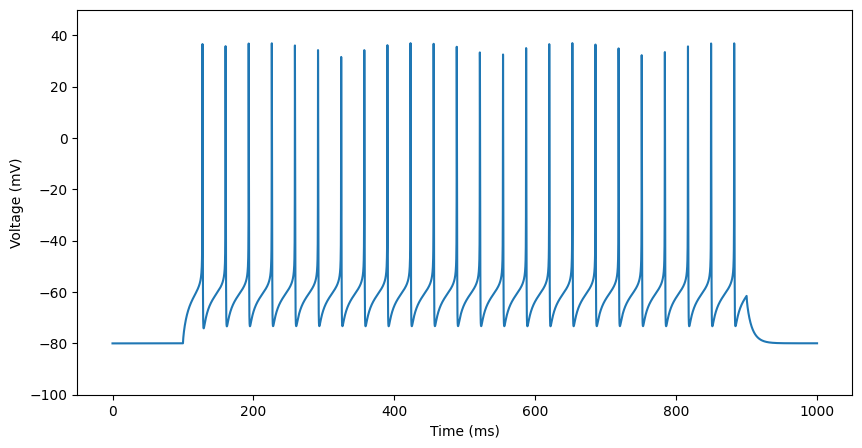

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(time_vec, voltages[0])
ax.set_ylim(-100, 50)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Voltage (mV)')

In [25]:
v_nrn = np.load('/content/v_nrn.npy')

Text(0, 0.5, 'Voltage (mV)')

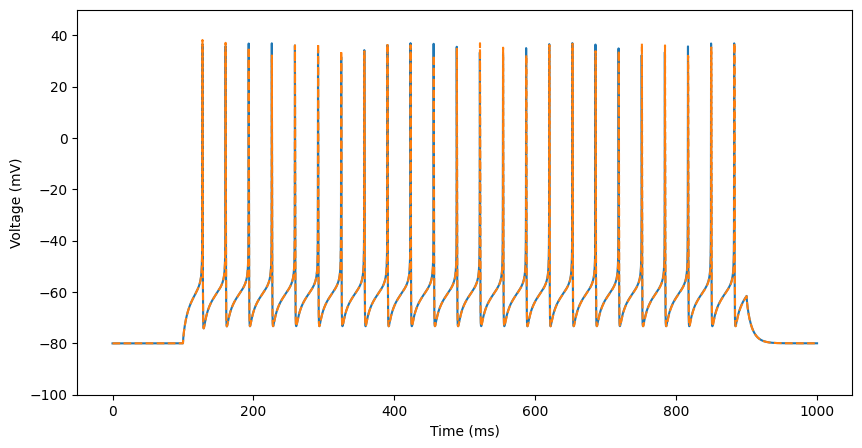

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(time_vec, voltages[0])
ax.plot(time_vec, v_nrn, linestyle='dashed')
ax.set_ylim(-100, 50)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Voltage (mV)')